# Binder Cumulant

In this notebook, we'd like to analyze Binder Cumulant for the system

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from src.analysis.data import load_experiment_result_data

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.style.use('default')
pd.set_option('mode.copy_on_write', True)

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [4]:
magnetization = load_experiment_result_data('../../results/erdos_renyi/magnetization.csv')

In [5]:
magnetization

alpha    10                                      20                    ...  \
beta    0.2    0.4    0.6    0.8    1.0    1.2  0.2   0.4   0.6   0.8  ...   
0      -106   -106   -106   -106   -106   -106 -106  -106  -106  -106  ...   
1       110     94   -186   -390   -678   -222   98    86  -170  -458  ...   
2       442    600   -332   -824  -1494   -738  422   592  -320  -634  ...   
3       402   1062   -936  -1744  -3442  -1770  422   936  -536 -1508  ...   
4       222    840  -1852  -3292  -6782  -3046  202   818 -1058 -3262  ...   
...     ...    ...    ...    ...    ...    ...  ...   ...   ...   ...  ...   
2996   -348  10416 -14858 -16306 -16912 -17294 -194  5262 -7602 -7576  ...   
2997   -230  10534 -14768 -16278 -16894 -17404  -34  5266 -7624 -7972  ...   
2998   -432  10448 -14448 -16064 -16906 -17490 -272  5296 -7340 -7872  ...   
2999  -1008  10148 -14470 -15956 -17128 -17752 -914  5024 -7456 -7660  ...   
3000   -724  10788 -14290 -15752 -16894 -17408 -688  5574 -6866 -7630  ...   

alpha    40                     50                                
beta    0.6   0.8   1.0   1.2  0.2   0.4   0.6   0.8   1.0   1.2  
0      -106  -106  -106  -106 -106  -106  -106  -106  -106  -106  
1      -196  -470  -500  -338  150   190  -102  -388  -446  -550  
2      -188  -562  -844  -376  506   764   -18  -336  -800  -608  
3      -254 -1032 -2092 -1032  398  1248  -158  -586 -1874 -1180  
4      -954 -2174 -3612 -1764  164  1376  -750 -1678 -2754 -2322  
...     ...   ...   ...   ...  ...   ...   ...   ...   ...   ...  
2996  -3350 -3696 -3828 -4146   14  1500 -2862 -2998 -3236 -3144  
2997  -3324 -3906 -3766 -4118  148  1898 -2976 -2970 -3386 -3012  
2998  -3666 -4134 -4076 -4208 -134  2048 -3110 -3234 -3174 -3224  
2999  -3684 -4178 -3868 -3892 -606  1972 -3166 -3176 -3208 -3380  
3000  -3098 -3546 -3974 -3744 -376  2416 -2642 -3258 -3066 -2986  

[3001 rows x 30 columns]

In [33]:
import numpy as np

def calculate_binder_cumulant(m_series, burn_in_ratio=0.2):
    # 1. 剔除過渡態
    start_idx = int(len(m_series) * burn_in_ratio)
    stable_m = m_series[start_idx:]
    
    # 2. 計算矩 (Moments)
    m2 = np.mean(stable_m**2)
    m4 = np.mean(stable_m**4)
    
    # 3. 計算 U4
    u4 = 1 - (m4 / (3 * (m2**2)))
    return u4

# 範例：對不同 beta 進行計算
beta_values = [0.2, 0.4, 0.6, 0.8, 1, 1.2] # 你的 beta 列表
u4_results = []

for beta in beta_values:
    m_t = magnetization[(50, beta)]
    res = calculate_binder_cumulant(m_t)
    u4_results.append(res)

In [34]:
u4_results

[np.float64(0.0712233968738577),
 np.float64(0.6298495789504146),
 np.float64(0.6566468996603525),
 np.float64(0.6601151234903031),
 np.float64(0.6612134654587043),
 np.float64(0.6622390852315465)]

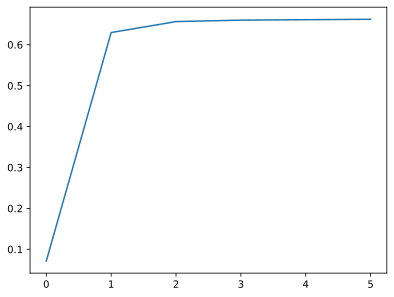

In [35]:
plt.plot(u4_results)
# TODO: 集中模擬 beta = 0.2 ~ 0.4 中間